In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv(r"C:\Users\Amey\Downloads\archive (9)\winequality-red.csv")

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [7]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


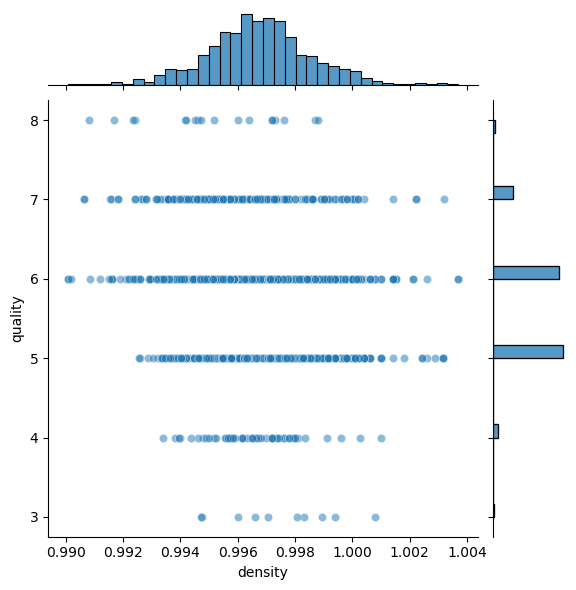

In [8]:
sns.jointplot(x='density', y ='quality' , data = df , alpha = 0.5 )

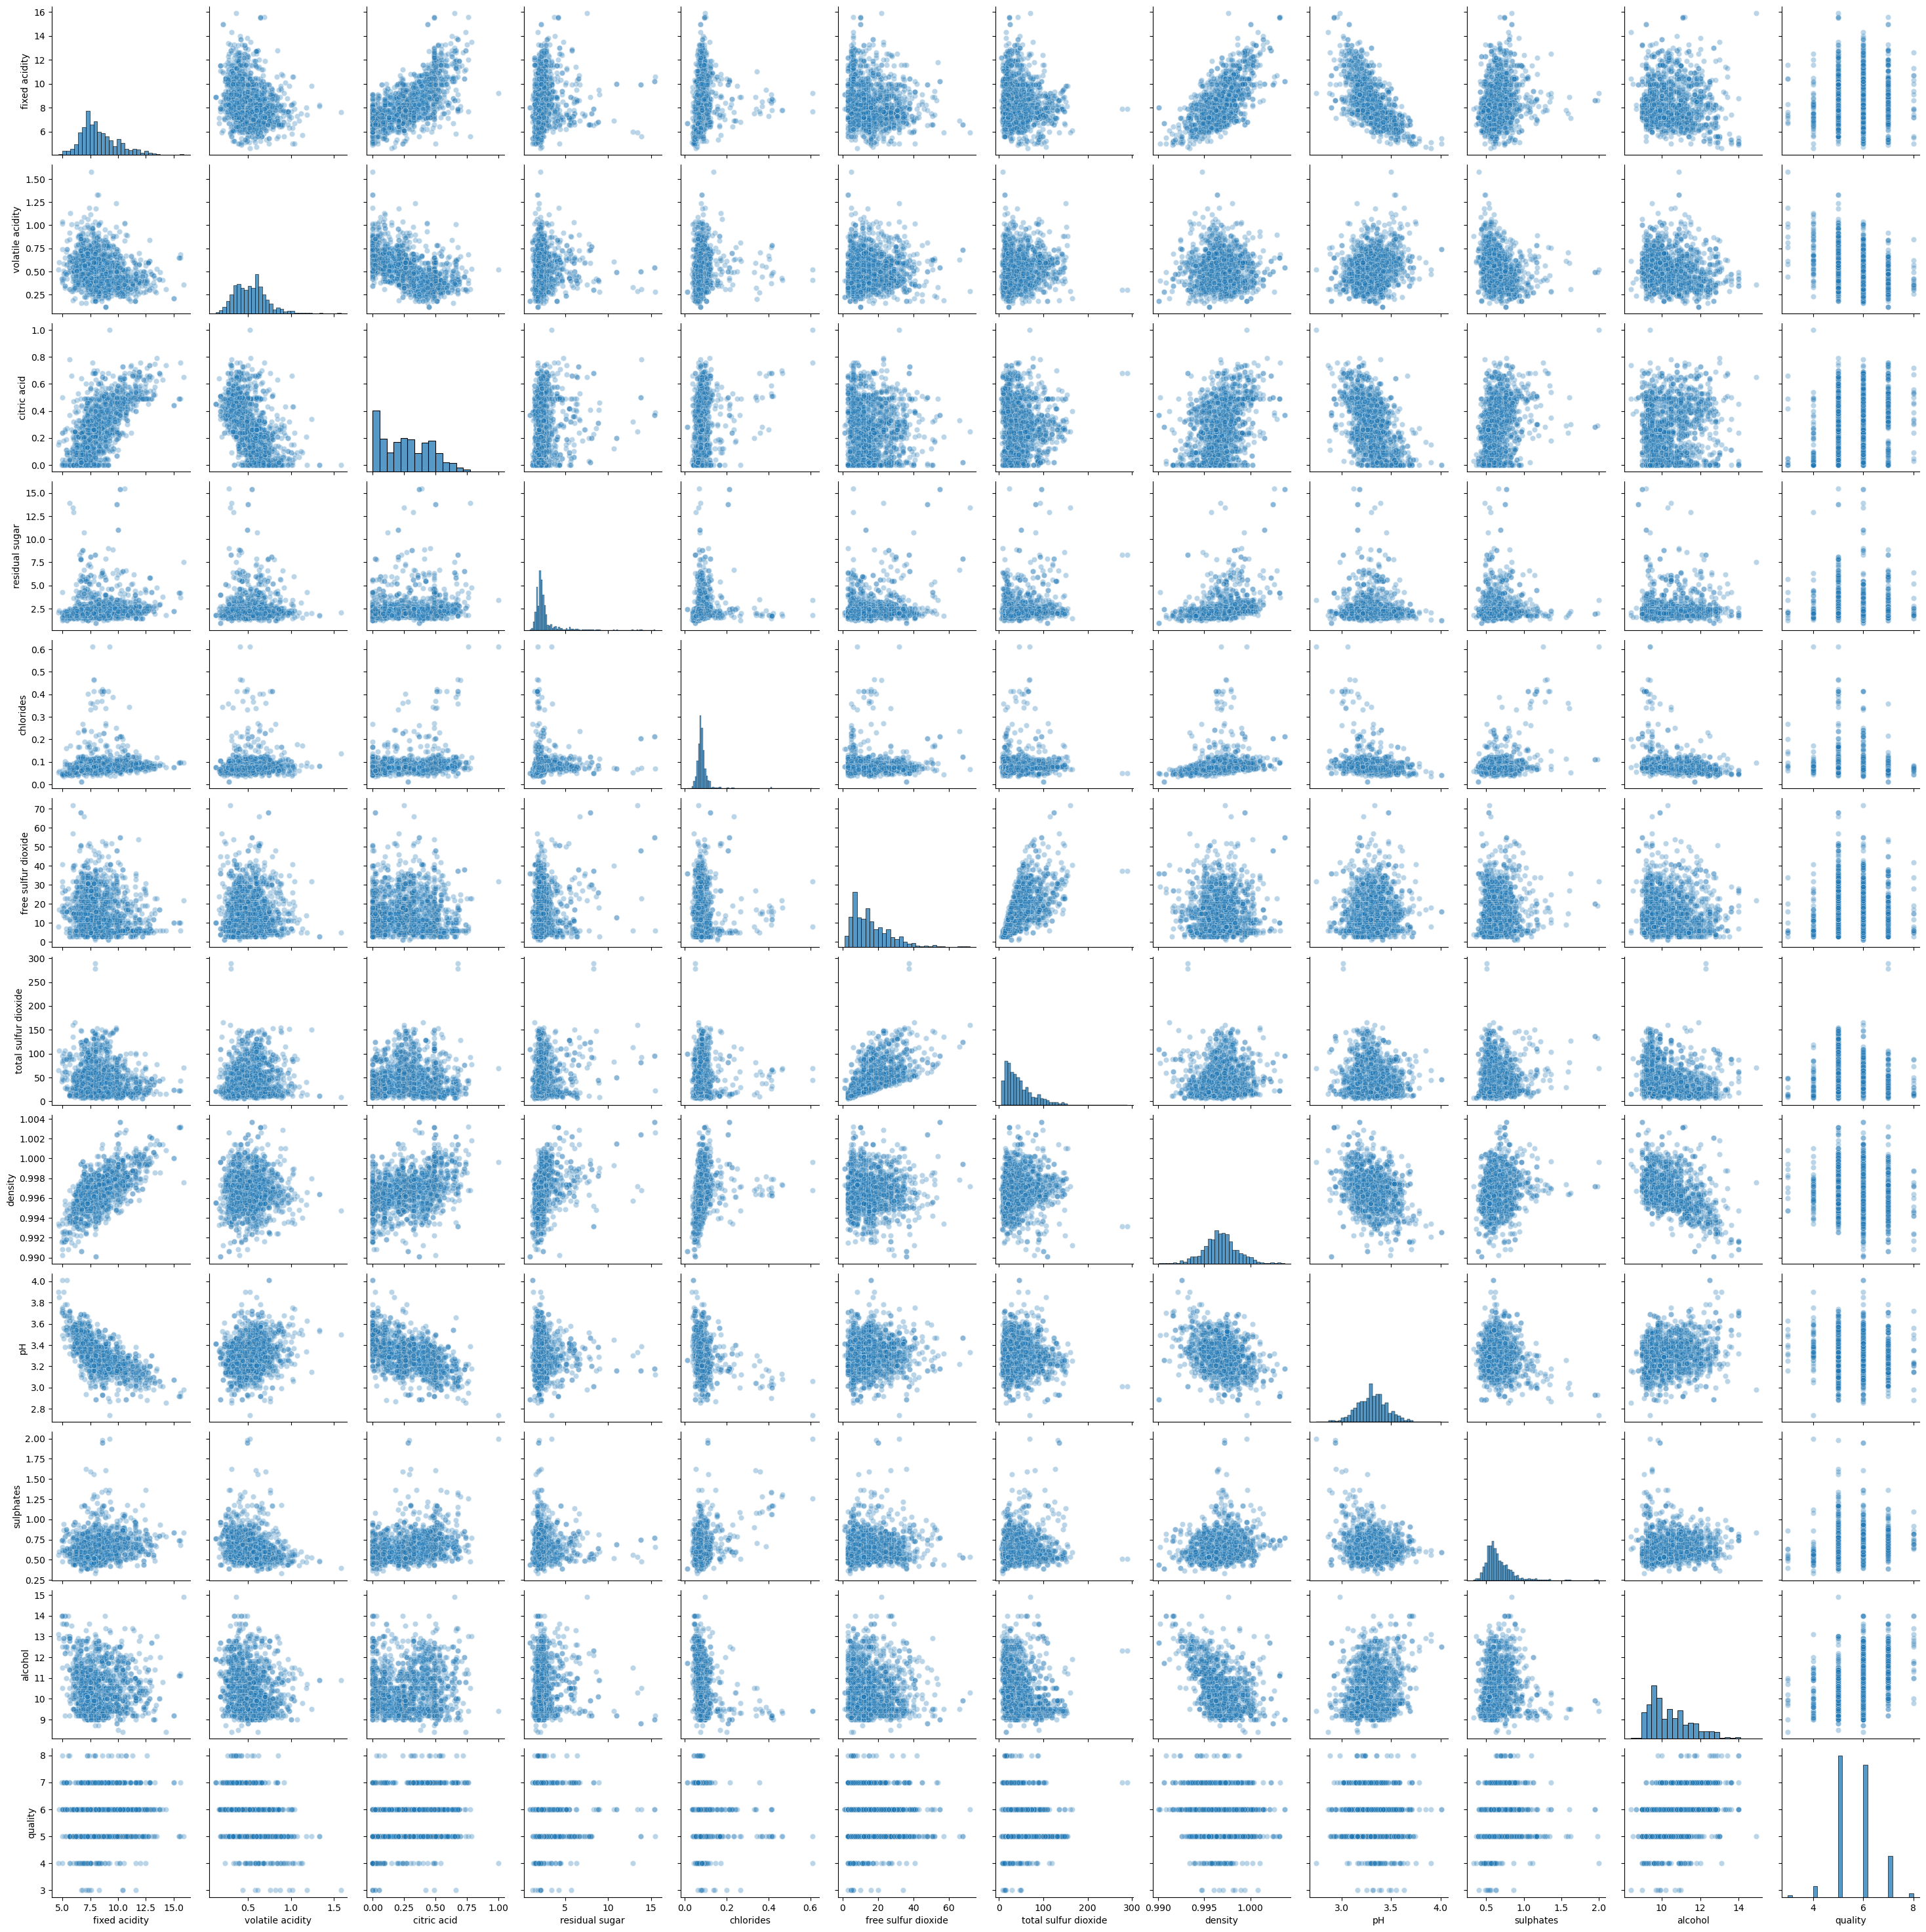

In [9]:
sns.pairplot(df, kind = 'scatter',plot_kws={'alpha':0.3})

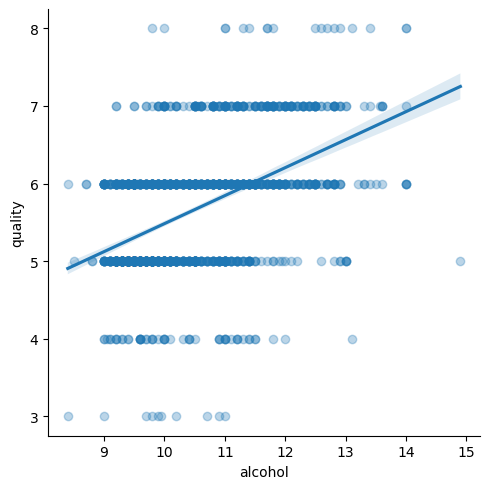

In [10]:
sns.lmplot(x='alcohol', y= 'quality' , data= df , scatter_kws={'alpha':0.3})

In [11]:
from sklearn.model_selection import train_test_split

In [12]:
X = df[['alcohol','sulphates','density','pH','total sulfur dioxide','free sulfur dioxide'
        ,'chlorides','residual sugar','citric acid','volatile acidity','fixed acidity']]
y = df['quality']

In [13]:
X_train , X_test , y_train , y_test = train_test_split(X,
                                                       y,
                                                       random_state=42,
                                                        test_size=0.2)

In [14]:
from sklearn.linear_model import LinearRegression

In [ ]:
lm = LinearRegression()

In [16]:
lm.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [17]:
X_test

,alcohol,sulphates,density,pH,total sulfur dioxide,free sulfur dioxide,chlorides,residual sugar,citric acid,volatile acidity,fixed acidity
803,9.6,0.66,0.99710,3.24,46.0,14.0,0.114,2.50,0.08,0.560,7.7
124,9.5,0.48,0.99600,3.39,102.0,21.0,0.082,1.60,0.17,0.500,7.8
350,9.9,0.98,1.00040,3.28,34.0,17.0,0.107,2.70,0.22,0.670,10.7
682,9.8,0.54,0.99800,3.33,58.0,32.0,0.078,2.25,0.31,0.460,8.5
1326,10.6,0.60,0.99480,3.39,34.0,18.0,0.077,1.70,0.24,0.460,6.7
...,...,...,...,...,...,...,...,...,...,...,...
1259,11.3,0.63,0.99538,3.44,33.0,15.0,0.123,2.70,0.00,0.640,6.8
1295,9.5,0.45,0.99558,3.20,77.5,51.0,0.093,4.30,0.00,0.630,6.6
1155,9.8,0.53,0.99616,3.15,38.0,9.0,0.118,2.20,0.25,0.600,8.3
963,11.2,0.69,0.99546,3.15,27.0,20.0,0.100,2.00,0.39,0.270,8.8


In [18]:
lm.coef_

array([ 2.81889567e-01,  8.41171623e-01, -1.03515936e+01, -3.93687732e-01,
       -3.64444893e-03,  5.62733439e-03, -1.80650315e+00,  6.56431104e-03,
       -1.40821461e-01, -1.00130443e+00,  2.30853339e-02])

In [19]:
cdf = pd.DataFrame(lm.coef_, X.columns , columns=['Coef'] )
cdf

,Coef
alcohol,0.281890
sulphates,0.841172
density,-10.351594
pH,-0.393688
total sulfur dioxide,-0.003644
free sulfur dioxide,0.005627
chlorides,-1.806503
residual sugar,0.006564
citric acid,-0.140821
volatile acidity,-1.001304


In [20]:
predictions = lm.predict(X_test)
predictions

array([5.34666441, 5.05631345, 5.66446972, 5.46451484, 5.72518476,
       5.27928659, 5.03421667, 5.12623347, 5.74534288, 5.68665032,
       6.13959677, 5.23386892, 5.54991474, 5.25825299, 5.44810502,
       6.46828999, 5.15018088, 5.59105157, 6.5560658 , 5.32255751,
       5.3918385 , 5.19610791, 5.94475739, 6.36197631, 5.35484893,
       5.41907575, 6.36483321, 5.35121573, 5.172392  , 6.16987311,
       5.25263058, 5.50657406, 5.75422105, 5.39101712, 5.45331031,
       5.02757499, 6.16173243, 5.68661555, 5.6486077 , 6.165471  ,
       5.52872593, 5.24414488, 6.17724727, 5.16500868, 5.87598332,
       5.81317121, 6.41982782, 5.6059474 , 5.15232137, 5.55634632,
       5.16044852, 5.10449459, 5.58371721, 6.33425313, 4.95134985,
       4.98364804, 6.01041999, 5.40809804, 5.83802638, 5.2486897 ,
       5.60717482, 5.96630957, 5.27619063, 5.30380113, 6.4949309 ,
       5.42033967, 6.34273471, 5.24618531, 6.41317317, 5.31237924,
       6.41746963, 4.74315748, 5.79362039, 5.8283184 , 6.17598

Text(0.5, 1.0, 'quality determination')

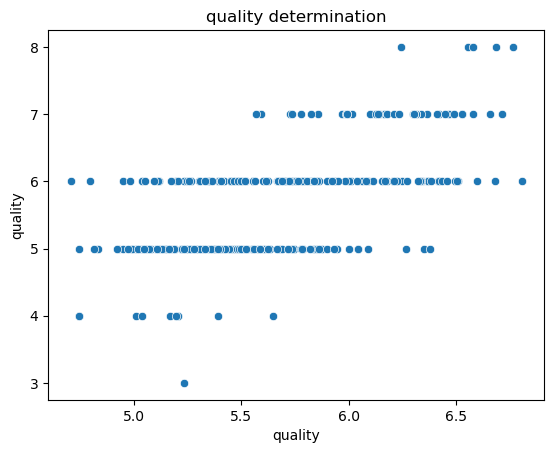

In [21]:
sns.scatterplot(x=predictions, y=y_test)
plt.xlabel("quality")
plt.title("quality determination")

In [22]:
from sklearn.metrics import mean_absolute_error , mean_squared_error
import math

In [23]:
print( "MAE:" ,mean_absolute_error(y_test,predictions))
print("MSE:" , mean_squared_error(y_test,predictions))
print("RMSE:" , math.sqrt(mean_squared_error(y_test,predictions))) 

MAE: 0.5035304415524375
MSE: 0.39002514396395344
RMSE: 0.6245199307980118


In [24]:
residuals = y_test - predictions
residuals

803     0.653336
124    -0.056313
350     0.335530
682    -0.464515
1326    0.274815
          ...   
1259    0.311847
1295   -0.232255
1155   -0.280535
963    -0.272466
704    -1.197072
Name: quality, Length: 320, dtype: float64

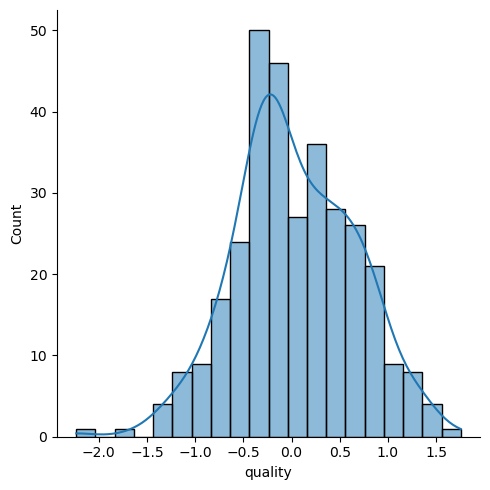

In [25]:
sns.displot(residuals, bins = 20 , kde = True)

<function matplotlib.pyplot.show(close=None, block=None)>

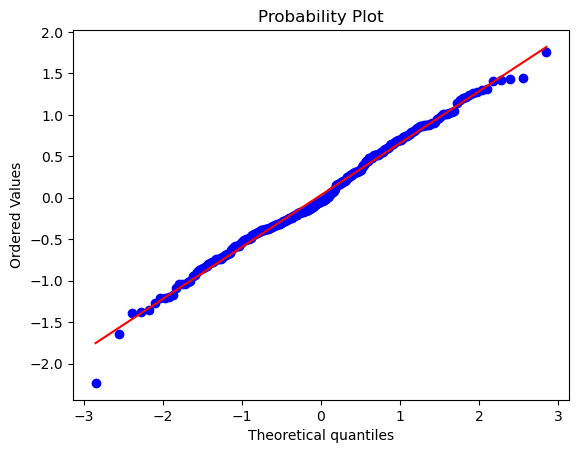

In [26]:
import pylab
import scipy.stats as stats

stats.probplot(
    residuals,
    dist = "norm",
    plot = pylab
)

pylab.show